In [667]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Any

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [668]:
BDF_DIR: Path = Path("../dataset/raw/bdf")

RATINGS_PATH: Path = Path(
    "../dataset/raw/metadata/participant_ratings.xls"
)
# RUSSELL
TARGET_SUBJECT: int = 28

In [669]:
ratings_df: pd.DataFrame = pd.read_excel(RATINGS_PATH)

ratings_df.head()

,Participant_id,Trial,Experiment_id,Start_time,Valence,Arousal,Dominance,Liking,Familiarity
0,1,1,5,1695918,6.96,3.92,7.19,6.05,4.0
1,1,2,18,2714905,7.23,7.15,6.94,8.01,4.0
2,1,3,4,3586768,4.94,6.01,6.12,8.06,4.0
3,1,4,24,4493800,7.04,7.09,8.01,8.22,4.0
4,1,5,20,5362005,8.26,7.91,7.19,8.13,1.0


In [670]:
subject_ratings: pd.DataFrame = ratings_df[
    ratings_df["Participant_id"] == TARGET_SUBJECT
].copy()

subject_ratings["start_sec"] = (
    subject_ratings["Start_time"] / 10000
)

subject_ratings[
    [
        "Trial",
        "Experiment_id",
        "Start_time",
        "start_sec",
    ]
].head(50)

,Trial,Experiment_id,Start_time,start_sec
1080,1,12,1903620,190.3620
1081,2,34,2764551,276.4551
1082,3,2,3597195,359.7195
1083,4,7,4400765,440.0765
1084,5,21,5192388,519.2388
1085,6,22,6023875,602.3875
1086,7,32,6865767,686.5767
1087,8,33,7706955,770.6955
1088,9,15,8486596,848.6596
1089,10,17,9307588,930.7588


In [671]:
def normalize_event_codes(
    event_codes: np.ndarray,
) -> np.ndarray:
    """
    Normalización actual usada en el proyecto.
    """
    normalized_codes: np.ndarray = (
        event_codes.copy().astype(int)
    )

    mask: np.ndarray = normalized_codes >= 1638144

    normalized_codes[mask] = (
        normalized_codes[mask] - 1638144
    )

    return normalized_codes


def find_status_channel(
    raw: mne.io.BaseRaw,
) -> str:
    """
    Detecta automáticamente el canal Status.
    """
    if "Status" in raw.ch_names:
        return "Status"

    if "-0" in raw.ch_names:
        return "-0"

    if "" in raw.ch_names:
        return ""

    raise ValueError(
        "No se encontró canal Status"
    )

In [672]:
bdf_path: Path = (
    BDF_DIR / f"s{TARGET_SUBJECT:02d}.bdf"
)

raw = mne.io.read_raw_bdf(
    bdf_path,
    preload=False,
    verbose=False,
)

status_channel: str = find_status_channel(raw)

print("Status channel:", repr(status_channel))

events: np.ndarray = mne.find_events(
    raw,
    stim_channel=status_channel,
    shortest_event=1,
    verbose=False,
)

events[:, 2] = normalize_event_codes(
    events[:, 2]
)

print("Total events:", len(events))

/tmp/ipykernel_41867/89745479.py:5: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_bdf(
/tmp/ipykernel_41867/89745479.py:5: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_bdf(


Status channel: ''
Total events: 297


In [673]:
codes, counts = np.unique(
    events[:, 2],
    return_counts=True,
)

distribution: Dict[int, int] = dict(
    zip(
        codes.astype(int).tolist(),
        counts.astype(int).tolist(),
    )
)

distribution

{1: 157,
 2: 4,
 3: 39,
 4: 37,
 5: 39,
 7: 1,
 4194304: 1,
 4194305: 11,
 4194307: 2,
 4194308: 3,
 4194309: 3}

In [674]:
event4_events: np.ndarray = events[
    events[:, 2] == 4
]

print("Num event 4:", len(event4_events))

event4_times_sec: np.ndarray = (
    event4_events[:, 0] / 512
)

event4_times_sec[:10]

Num event 4: 37


array([219.47460938, 305.54492188, 388.83203125, 469.1875    ,
       548.32617188, 631.49804688, 715.68359375, 799.8046875 ,
       877.74414062, 959.86523438])

In [675]:
comparison_rows: List[Dict[str, Any]] = []

min_trials: int = min(
    len(subject_ratings),
    len(event4_times_sec),
)

for index in range(min_trials):
    rating_row = subject_ratings.iloc[index]

    rating_start_sec: float = float(
        rating_row["start_sec"]
    )

    event4_sec: float = float(
        event4_times_sec[index]
    )

    difference_sec: float = (
        event4_sec - rating_start_sec
    )

    comparison_rows.append(
        {
            "Trial": int(rating_row["Trial"]),
            "Experiment_id": int(
                rating_row["Experiment_id"]
            ),
            "rating_start_sec": rating_start_sec,
            "event4_sec": event4_sec,
            "difference_sec": difference_sec,
        }
    )

comparison_df: pd.DataFrame = pd.DataFrame(
    comparison_rows
)

comparison_df.head(50)
# RUSSELL

,Trial,Experiment_id,rating_start_sec,event4_sec,difference_sec
0,1,12,190.3620,219.474609,29.112609
1,2,34,276.4551,305.544922,29.089822
2,3,2,359.7195,388.832031,29.112531
3,4,7,440.0765,469.187500,29.111000
4,5,21,519.2388,548.326172,29.087372
5,6,22,602.3875,631.498047,29.110547
6,7,32,686.5767,715.683594,29.106894
7,8,33,770.6955,799.804688,29.109187
8,9,15,848.6596,877.744141,29.084541
9,10,17,930.7588,959.865234,29.106434


In [676]:
comparison_df["difference_sec"].describe()

count     37.000000
mean     101.855332
std       97.346560
min       29.076181
25%       29.099066
50%       29.109187
75%      200.301362
max      294.482150
Name: difference_sec, dtype: float64

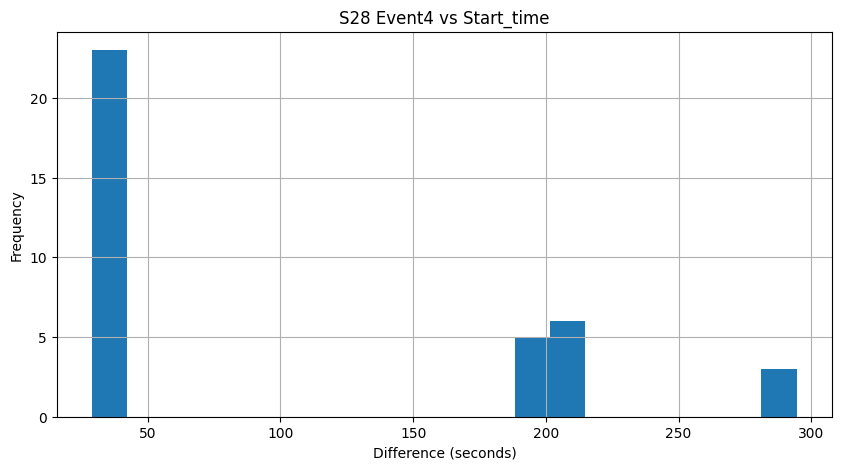

In [677]:
plt.figure(figsize=(10, 5))

plt.hist(
    comparison_df["difference_sec"],
    bins=20,
)

plt.xlabel("Difference (seconds)")
plt.ylabel("Frequency")

plt.title(
    f"S{TARGET_SUBJECT:02d} "
    "Event4 vs Start_time"
)

plt.grid(True)

plt.show()

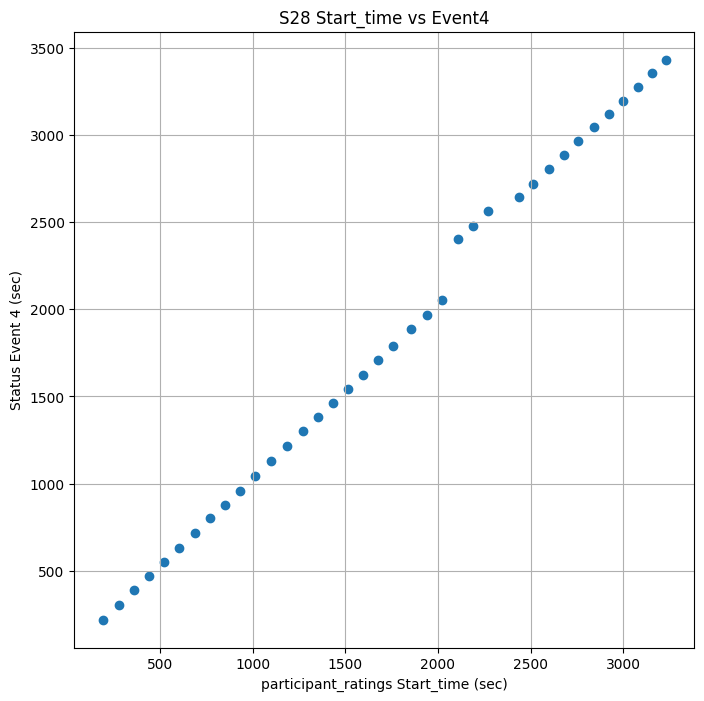

In [678]:
plt.figure(figsize=(8, 8))

plt.scatter(
    comparison_df["rating_start_sec"],
    comparison_df["event4_sec"],
)

plt.xlabel("participant_ratings Start_time (sec)")
plt.ylabel("Status Event 4 (sec)")

plt.title(
    f"S{TARGET_SUBJECT:02d} "
    "Start_time vs Event4"
)

plt.grid(True)

plt.show()

In [679]:
relevant_events: np.ndarray = events[
    np.isin(events[:, 2], [3, 4, 5])
]

for index, event in enumerate(relevant_events):
    sample: int = int(event[0])

    code: int = int(event[2])

    time_sec: float = sample / 512

    print(
        f"{index:03d} | "
        f"time={time_sec:.3f}s | "
        f"code={code}"
    )

000 | time=28.107s | code=3
001 | time=50.051s | code=5
002 | time=80.174s | code=5
003 | time=214.426s | code=3
004 | time=219.475s | code=4
005 | time=279.570s | code=5
006 | time=300.514s | code=3
007 | time=305.545s | code=4
008 | time=365.607s | code=5
009 | time=383.783s | code=3
010 | time=388.832s | code=4
011 | time=448.877s | code=5
012 | time=464.139s | code=3
013 | time=469.188s | code=4
014 | time=529.232s | code=5
015 | time=543.295s | code=3
016 | time=548.326s | code=4
017 | time=608.371s | code=5
018 | time=626.449s | code=3
019 | time=631.498s | code=4
020 | time=691.527s | code=5
021 | time=710.637s | code=3
022 | time=715.684s | code=4
023 | time=775.746s | code=5
024 | time=794.756s | code=3
025 | time=799.805s | code=4
026 | time=859.834s | code=5
027 | time=872.713s | code=3
028 | time=877.744s | code=4
029 | time=937.807s | code=5
030 | time=954.818s | code=3
031 | time=959.865s | code=4
032 | time=1019.912s | code=5
033 | time=1036.672s | code=3
034 | time=1041

In [680]:
relevant_codes: List[int] = (
    relevant_events[:, 2]
    .astype(int)
    .tolist()
)

for index in range(len(relevant_codes) - 2):
    window: List[int] = (
        relevant_codes[index:index + 3]
    )

    if window != [3, 4, 5]:
        print(
            f"Broken pattern at index {index}:",
            window
        )

Broken pattern at index 0: [3, 5, 5]
Broken pattern at index 1: [5, 5, 3]
Broken pattern at index 2: [5, 3, 4]
Broken pattern at index 4: [4, 5, 3]
Broken pattern at index 5: [5, 3, 4]
Broken pattern at index 7: [4, 5, 3]
Broken pattern at index 8: [5, 3, 4]
Broken pattern at index 10: [4, 5, 3]
Broken pattern at index 11: [5, 3, 4]
Broken pattern at index 13: [4, 5, 3]
Broken pattern at index 14: [5, 3, 4]
Broken pattern at index 16: [4, 5, 3]
Broken pattern at index 17: [5, 3, 4]
Broken pattern at index 19: [4, 5, 3]
Broken pattern at index 20: [5, 3, 4]
Broken pattern at index 22: [4, 5, 3]
Broken pattern at index 23: [5, 3, 4]
Broken pattern at index 25: [4, 5, 3]
Broken pattern at index 26: [5, 3, 4]
Broken pattern at index 28: [4, 5, 3]
Broken pattern at index 29: [5, 3, 4]
Broken pattern at index 31: [4, 5, 3]
Broken pattern at index 32: [5, 3, 4]
Broken pattern at index 34: [4, 5, 3]
Broken pattern at index 35: [5, 3, 4]
Broken pattern at index 37: [4, 5, 3]
Broken pattern at i

In [681]:
relevant_events = events[
    np.isin(events[:, 2], [3, 4, 5])
]

for index, event in enumerate(relevant_events):
    sample = int(event[0])

    code = int(event[2])

    time_sec = sample / 512

    print(
        f"{index:03d} | "
        f"time={time_sec:.3f}s | "
        f"code={code}"
    )

000 | time=28.107s | code=3
001 | time=50.051s | code=5
002 | time=80.174s | code=5
003 | time=214.426s | code=3
004 | time=219.475s | code=4
005 | time=279.570s | code=5
006 | time=300.514s | code=3
007 | time=305.545s | code=4
008 | time=365.607s | code=5
009 | time=383.783s | code=3
010 | time=388.832s | code=4
011 | time=448.877s | code=5
012 | time=464.139s | code=3
013 | time=469.188s | code=4
014 | time=529.232s | code=5
015 | time=543.295s | code=3
016 | time=548.326s | code=4
017 | time=608.371s | code=5
018 | time=626.449s | code=3
019 | time=631.498s | code=4
020 | time=691.527s | code=5
021 | time=710.637s | code=3
022 | time=715.684s | code=4
023 | time=775.746s | code=5
024 | time=794.756s | code=3
025 | time=799.805s | code=4
026 | time=859.834s | code=5
027 | time=872.713s | code=3
028 | time=877.744s | code=4
029 | time=937.807s | code=5
030 | time=954.818s | code=3
031 | time=959.865s | code=4
032 | time=1019.912s | code=5
033 | time=1036.672s | code=3
034 | time=1041

___

In [682]:
TARGET_SUBJECT: int = 28

subject_ratings = ratings_df[
    ratings_df["Participant_id"] == TARGET_SUBJECT
].copy()

subject_ratings["start_sec"] = subject_ratings["Start_time"] / 10000

subject_ratings = subject_ratings.sort_values("Trial").reset_index(drop=True)

subject_ratings[
    ["Trial", "Experiment_id", "start_sec", "Valence", "Arousal", "Dominance", "Liking", "Familiarity"]
]

,Trial,Experiment_id,start_sec,Valence,Arousal,Dominance,Liking,Familiarity
0,1,12,190.3620,6.06,2.05,5.04,5.99,1.0
1,2,34,276.4551,5.99,7.06,7.03,6.00,1.0
2,3,2,359.7195,7.99,8.10,8.06,9.00,1.0
3,4,7,440.0765,8.09,9.00,7.08,9.00,4.0
4,5,21,519.2388,2.01,1.95,3.00,4.95,1.0
5,6,22,602.3875,5.03,1.00,5.00,2.05,1.0
6,7,32,686.5767,3.05,7.05,8.01,3.03,3.0
7,8,33,770.6955,7.01,7.92,9.00,7.06,1.0
8,9,15,848.6596,5.04,1.00,3.03,2.01,1.0
9,10,17,930.7588,6.99,3.09,7.05,6.97,1.0


In [683]:
valid_comparison = comparison_df[
    comparison_df["difference_sec"].between(20, 40)
].copy()

offset_sec: float = float(valid_comparison["difference_sec"].median())

print("Offset estimado S28:", offset_sec)
print(valid_comparison["difference_sec"].describe())

Offset estimado S28: 29.100362500000074
count    23.000000
mean     29.096948
std       0.012814
min      29.076181
25%      29.083158
50%      29.100363
75%      29.106698
max      29.112609
Name: difference_sec, dtype: float64


In [684]:
reconstructed_rows = []

for _, row in subject_ratings.iterrows():
    trial: int = int(row["Trial"])
    experiment_id: int = int(row["Experiment_id"])

    during_start_sec: float = float(row["start_sec"] + offset_sec)
    before_start_sec: float = during_start_sec - 5.0
    after_start_sec: float = during_start_sec + 60.0
    end_sec: float = after_start_sec + 3.0

    reconstructed_rows.append({
        "Trial": trial,
        "Experiment_id": experiment_id,
        "rating_start_sec": float(row["start_sec"]),
        "before_start_sec": before_start_sec,
        "during_start_sec": during_start_sec,
        "after_start_sec": after_start_sec,
        "end_sec": end_sec,
        "before_start_sample_512": int(round(before_start_sec * 512)),
        "during_start_sample_512": int(round(during_start_sec * 512)),
        "after_start_sample_512": int(round(after_start_sec * 512)),
        "end_sample_512": int(round(end_sec * 512)),
    })

s28_reconstructed_trials_df = pd.DataFrame(reconstructed_rows)

s28_reconstructed_trials_df

,Trial,Experiment_id,rating_start_sec,before_start_sec,during_start_sec,after_start_sec,end_sec,before_start_sample_512,during_start_sample_512,after_start_sample_512,end_sample_512
0,1,12,190.3620,214.462363,219.462363,279.462363,282.462363,109805,112365,143085,144621
1,2,34,276.4551,300.555463,305.555463,365.555463,368.555463,153884,156444,187164,188700
2,3,2,359.7195,383.819863,388.819863,448.819863,451.819863,196516,199076,229796,231332
3,4,7,440.0765,464.176863,469.176863,529.176863,532.176863,237659,240219,270939,272475
4,5,21,519.2388,543.339163,548.339163,608.339163,611.339163,278190,280750,311470,313006
5,6,22,602.3875,626.487863,631.487863,691.487863,694.487863,320762,323322,354042,355578
6,7,32,686.5767,710.677063,715.677063,775.677063,778.677063,363867,366427,397147,398683
7,8,33,770.6955,794.795863,799.795863,859.795863,862.795863,406935,409495,440215,441751
8,9,15,848.6596,872.759963,877.759963,937.759963,940.759963,446853,449413,480133,481669
9,10,17,930.7588,954.859163,959.859163,1019.859163,1022.859163,488888,491448,522168,523704


In [685]:
status_event_rows = []

for event in relevant_events:
    status_event_rows.append({
        "event_time_sec": float(event[0] / 512),
        "event_code": int(event[2]),
    })

status_events_df = pd.DataFrame(status_event_rows)

status_events_df.head()

,event_time_sec,event_code
0,28.107422,3
1,50.050781,5
2,80.173828,5
3,214.425781,3
4,219.474609,4


In [ ]:
def find_nearest_event_time(
    target_time: float,
    event_code: int,
    tolerance_sec: float = 1.0,
) -> float | None:
    candidates = status_events_df[1879.677734
        status_events_df["event_code"] == event_code
    ].copy()

    if candidates.empty:
        return None

    candidates["abs_diff"] = (
        candidates["event_time_sec"] - target_time
    ).abs()

    nearest = candidates.sort_values("abs_diff").iloc[0]

    if float(nearest["abs_diff"]) <= tolerance_sec:
        return float(nearest["event_time_sec"])

    return None


checked_rows = []

for _, row in s28_reconstructed_trials_df.iterrows():
    before_status = find_nearest_event_time(row["before_start_sec"], 3)
    during_status = find_nearest_event_time(row["during_start_sec"], 4)
    after_status = find_nearest_event_time(row["after_start_sec"], 5)

    checked_rows.append({
        **row.to_dict(),
        "status_before_found": before_status,
        "status_during_found": during_status,
        "status_after_found": after_status,
        "before_source": "status" if before_status is not None else "reconstructed",
        "during_source": "status" if during_status is not None else "reconstructed",
        "after_source": "status" if after_status is not None else "reconstructed",
    })

s28_checked_trials_df = pd.DataFrame(checked_rows)

s28_checked_trials_df[
    [
        "Trial",
        "Experiment_id",
        "before_start_sec",
        "during_start_sec",
        "after_start_sec",
        "status_before_found",
        "status_during_found",
        "status_after_found",
        "before_source",
        "during_source",
        "after_source",
    ]
]

,Trial,Experiment_id,before_start_sec,during_start_sec,after_start_sec,status_before_found,status_during_found,status_after_found,before_source,during_source,after_source
0,1.0,12.0,214.462363,219.462363,279.462363,214.425781,219.474609,279.570312,status,status,status
1,2.0,34.0,300.555463,305.555463,365.555463,300.513672,305.544922,365.607422,status,status,status
2,3.0,2.0,383.819863,388.819863,448.819863,383.783203,388.832031,448.876953,status,status,status
3,4.0,7.0,464.176863,469.176863,529.176863,464.138672,469.187500,529.232422,status,status,status
4,5.0,21.0,543.339163,548.339163,608.339163,543.294922,548.326172,608.371094,status,status,status
5,6.0,22.0,626.487863,631.487863,691.487863,626.449219,631.498047,691.527344,status,status,status
6,7.0,32.0,710.677063,715.677063,775.677063,710.636719,715.683594,775.746094,status,status,status
7,8.0,33.0,794.795863,799.795863,859.795863,794.755859,799.804688,859.833984,status,status,status
8,9.0,15.0,872.759963,877.759963,937.759963,872.712891,877.744141,937.806641,status,status,status
9,10.0,17.0,954.859163,959.859163,1019.859163,954.818359,959.865234,1019.912109,status,status,status
